In [1]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("/scratch/gpfs/jp7427/FVvsSD/sinus-timing/timing_results.csv")

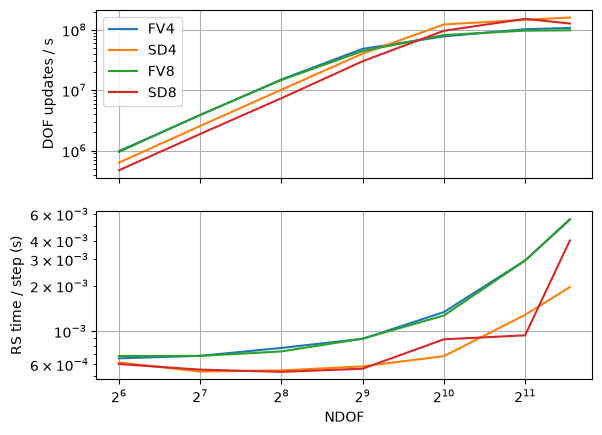

In [3]:
fig, axs = plt.subplots(2, 1, sharex=True)
axs[1].set_xlabel("NDOF")
axs[0].set_ylabel("DOF updates / s")
axs[1].set_ylabel("RS time / step (s)")
axs[0].set_xscale("log", base=2)
axs[0].set_yscale("log")
axs[1].set_yscale("log")

def plot(ax, df, quantity, **kwargs):
    if quantity == "update_rate":
        ax.plot(df.NDOF, df.update_rate, **kwargs)
    elif quantity == "rs_per_step":
        ax.plot(df.NDOF, df.rs_per_step, **kwargs)

plot(axs[0], df[(df.scheme == "FV") & (df.p == 3)], "update_rate", label="FV4")
plot(axs[1], df[(df.scheme == "FV") & (df.p == 3)], "rs_per_step", label="FV4")

plot(axs[0], df[(df.scheme == "SD") & (df.p == 3)], "update_rate", label="SD4")
plot(axs[1], df[(df.scheme == "SD") & (df.p == 3)], "rs_per_step", label="SD4")

plot(axs[0], df[(df.scheme == "FV") & (df.p == 7)], "update_rate", label="FV8")
plot(axs[1], df[(df.scheme == "FV") & (df.p == 7)], "rs_per_step", label="FV8")

plot(axs[0], df[(df.scheme == "SD") & (df.p == 7)], "update_rate", label="SD8")
plot(axs[1], df[(df.scheme == "SD") & (df.p == 7)], "rs_per_step", label="SD8")


axs[0].grid()
axs[1].grid()
axs[0].legend()

fig.savefig("update-rates.pdf", bbox_inches="tight")